# ResNet-50 – Soft Equivariance Feature Visualization

This notebook demonstrates how the **softness parameter** controls the degree of rotation equivariance in a pretrained ResNet-50 backbone.

## What we visualize

For each softness value we animate over **n_rotations** discrete rotation angles θ and show:

| Row | Content | Meaning |
|---|---|---|
| Top | **f(x)** | Feature map of the *original* image (fixed reference) |
| Bottom | **R⁻¹ f(Rx)** | Feature map of the *rotated* image, rotated back by R⁻¹ |

For a perfectly equivariant model (softness = 0), the two rows should be identical.
As softness increases toward 1 the model becomes less equivariant and the rows diverge.

Four GIFs are produced, one per softness value: **0.0, 0.2, 0.6, 1.0**.  
Features are extracted from the **final residual stage** of ResNet-50 (before global average pooling),
giving a `(2048, 7, 7)` spatial feature map.

In [1]:
import sys, os
sys.path.insert(0, '..')

import copy
import torch
import numpy as np
import matplotlib
matplotlib.use('Agg')          # non-interactive backend required for saving
import matplotlib.pyplot as plt
from scipy.ndimage import rotate as ndimage_rotate
from PIL import Image
import requests
from io import BytesIO
from transformers import AutoImageProcessor, ResNetForImageClassification
from IPython.display import Image as IPImage, display

from models.convert_cnn import convert_cnn_to_filtered

/home/rahman79/miniconda3/envs/softeq/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

All tunable parameters live here.

In [2]:
# ---------- Animation ----------
n_rotations     = 4                        # Number of rotation steps (e.g. 4 → 0°, 90°, 180°, 270°)
softness_values = [0.0, 0.2, 0.6, 1.0]    # Softness values to visualize (one GIF each)
viz_channels    = [0, 1, 2, 3, 4, 5]      # Which feature-map channels to display

# ---------- Filter (equivariance group) ----------
filter_n_rotations = 4          # Discrete rotation group size C_n (4 → C4 symmetry)
filter_group_type  = 'rotation' # 'rotation' or 'roto_reflection'

# ---------- Model ----------
model_name = 'microsoft/resnet-50'

# ---------- Output ----------
output_dir = 'figs'
os.makedirs(output_dir, exist_ok=True)

## 2. Load ResNet-50 Backbone and Build Filtered Models

We use `ResNetForImageClassification` from HuggingFace. For each softness value we
**deep-copy** the base model and apply `convert_cnn_to_filtered`, which replaces
all `Conv2d` layers (kernel ≥ 3) with rotation-filtered convolutions.

Note: when `soft_thresholding = 1.0` the conversion is skipped and the original
pretrained weights are used unchanged — this is the unconstrained baseline.

In [3]:
processor  = AutoImageProcessor.from_pretrained(model_name)
base_model = ResNetForImageClassification.from_pretrained(model_name)
base_model.eval()

# Probe feature map shape with a dummy forward pass
_dummy_feat = {}
def _probe_hook(module, inp, out):
    _dummy_feat['shape'] = tuple(out.shape)
_h = base_model.resnet.encoder.stages[-1].register_forward_hook(_probe_hook)
with torch.no_grad():
    _dummy = processor(images=Image.new('RGB', (224, 224)), return_tensors='pt')
    base_model(**_dummy)
_h.remove()

_, feat_channels, feat_h, feat_w = _dummy_feat['shape']
print(f'Model         : {model_name}')
print(f'Feature map   : ({feat_channels}, {feat_h}, {feat_w})  — final residual stage output')

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Model         : microsoft/resnet-50
Feature map   : (2048, 7, 7)  — final residual stage output


In [4]:
def build_filtered_model(base_model, softness):
    """Deep-copy the ResNet backbone and inject rotation filters with given softness."""
    model = copy.deepcopy(base_model)
    filter_config = {
        'n_rotations'        : filter_n_rotations,
        'soft_thresholding'  : softness,
        'decomposition_method': 'svd',
        'group_type'         : filter_group_type,
        'hard_mask'          : False,
        'preserve_norm'      : False,
        'joint_decomposition': True,
        'min_kernel_size'    : 3,
    }
    convert_cnn_to_filtered(model, filter_config)
    model.eval()
    return model

print('Building filtered models...')
models = {}
for s in softness_values:
    print(f'\n  softness = {s:.1f}')
    models[s] = build_filtered_model(base_model, s)
print('\nDone.')

Building filtered models...

  softness = 0.0
Converting CNN with filter config:
  group_type=rotation, n_rotations=4
  soft_thresholding=0.0, method=svd
  min_kernel_size=3, skip_first_conv=False
last_basis_idx and total basis: tensor(12) 49
  Replaced: Conv2d(3, 64, kernel=7)
last_basis_idx and total basis: tensor(2) 9
  Replaced: Conv2d(64, 64, kernel=3)
last_basis_idx and total basis: tensor(2) 9
  Replaced: Conv2d(64, 64, kernel=3)
last_basis_idx and total basis: tensor(2) 9
  Replaced: Conv2d(64, 64, kernel=3)
last_basis_idx and total basis: tensor(2) 9
  Replaced: Conv2d(128, 128, kernel=3)
last_basis_idx and total basis: tensor(2) 9
  Replaced: Conv2d(128, 128, kernel=3)
last_basis_idx and total basis: tensor(2) 9
  Replaced: Conv2d(128, 128, kernel=3)
last_basis_idx and total basis: tensor(2) 9
  Replaced: Conv2d(128, 128, kernel=3)
last_basis_idx and total basis: tensor(2) 9
  Replaced: Conv2d(256, 256, kernel=3)
last_basis_idx and total basis: tensor(2) 9
  Replaced: Conv2d(

## 3. Load Sample Image

In [5]:
url = 'http://images.cocodataset.org/val2017/000000078823.jpg'  # centered bird
response = requests.get(url)
raw = Image.open(BytesIO(response.content)).convert('RGB')

# Center-crop to square, then resize
w, h  = raw.size
side  = min(w, h)
left  = (w - side) // 2
top   = (h - side) // 2
image = raw.crop((left, top, left + side, top + side)).resize((224, 224), Image.LANCZOS)

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.title('Input Image (center-cropped square)')
plt.axis('off')
plt.tight_layout()
plt.savefig(f'{output_dir}/input_image.png', dpi=80)
plt.show()

## 4. Feature Extraction and Rotation Helpers

In [6]:
def extract_features(model, pil_image):
    """
    Run PIL image through the ResNet backbone and return the spatial feature map
    from the final residual stage (before global average pooling).

    Returns
    -------
    feat : Tensor of shape (feat_channels, feat_h, feat_w)
    """
    captured = {}
    def _hook(module, inp, out):
        captured['feat'] = out.detach()
    handle = model.resnet.encoder.stages[-1].register_forward_hook(_hook)
    inputs = processor(images=pil_image, return_tensors='pt')
    with torch.no_grad():
        model(**inputs)
    handle.remove()
    return captured['feat'][0]   # (C, H, W)


def rotate_pil(pil_image, angle_deg):
    """Rotate a PIL image counter-clockwise by angle_deg degrees."""
    return pil_image.rotate(angle_deg, resample=Image.BILINEAR, expand=False)


def rotate_feature_map(feat, angle_deg):
    """
    Rotate a spatial feature map counter-clockwise by angle_deg degrees.

    Parameters
    ----------
    feat      : Tensor of shape (C, H, W)
    angle_deg : float – rotation angle in degrees (positive = CCW)

    Returns
    -------
    Tensor of same shape (C, H, W)
    """
    feat_np = feat.numpy()
    rotated = np.stack([
        ndimage_rotate(feat_np[c], angle_deg, reshape=False, order=1)
        for c in range(feat_np.shape[0])
    ])
    return torch.tensor(rotated)

## 5. Pre-compute Features

We run all models on the original image and on every rotated version once,
storing results in memory to make GIF rendering fast.

In [7]:
angles = np.linspace(0, 360, n_rotations, endpoint=False)   # e.g. [0, 90, 180, 270]

# f(x) – features of the original image for each model
print('Computing f(x) for each softness…')
feat_original = {}
for s, model in models.items():
    feat_original[s] = extract_features(model, image)
    print(f'  softness={s:.1f}  shape={tuple(feat_original[s].shape)}')

# f(Rx) – features of each rotated image for each model
print('\nComputing f(Rx) for all rotations and softness values…')
feat_rotated = {s: [] for s in softness_values}

for i, angle in enumerate(angles):
    rotated_img = rotate_pil(image, angle)
    for s, model in models.items():
        feat_rotated[s].append(extract_features(model, rotated_img))
    print(f'  {i + 1}/{n_rotations} rotations done')

print('\nPre-computation complete.')

Computing f(x) for each softness…
  softness=0.0  shape=(2048, 7, 7)
  softness=0.2  shape=(2048, 7, 7)
  softness=0.6  shape=(2048, 7, 7)
  softness=1.0  shape=(2048, 7, 7)

Computing f(Rx) for all rotations and softness values…
  1/4 rotations done
  2/4 rotations done
  3/4 rotations done
  4/4 rotations done

Pre-computation complete.


## 6. Generate GIFs

For each softness value we create an animated GIF with `n_rotations` frames.

**Layout per frame (2 rows × 7 columns):**

```
┌──────────────┬────┬────┬────┬────┬────┬────┐
│  Rotated     │ f(x) channels 0–5             │
│  image Rθ(x) │                               │  ← fixed reference
├──────────────┼────┴────┴────┴────┴────┴────┤
│  Error map   │ R⁻¹f(Rx) channels 0–5        │
│  (mean |Δ|)  │                               │  ← changes with θ
└──────────────┴───────────────────────────────┘
```

Error is averaged over **all** `feat_channels` channels.  
All colorbars are fixed to a single global scale computed across all softness values × rotations.

In [8]:
# --- Precompute global scales for both error and feature maps -----------------------
print('Precomputing raw-space errors (all channels) and feature ranges…')
precomp_errors  = {}   # precomp_errors[s][frame_idx]  → (H, W) mean error over ALL channels
precomp_inv_fRx = {}   # precomp_inv_fRx[s][frame_idx] → (C, H, W) rotated-back features

all_err_vals  = []
all_feat_vals = []

for s in softness_values:
    fx_full = feat_original[s]   # (feat_channels, H, W)
    fx_np   = fx_full.numpy()
    precomp_errors[s]  = []
    precomp_inv_fRx[s] = []

    # Collect reference feature values for viz channels
    for ch in viz_channels:
        all_feat_vals.append(fx_np[ch].ravel())

    for frame_idx in range(n_rotations):
        inv_fRx = rotate_feature_map(feat_rotated[s][frame_idx], -angles[frame_idx])
        precomp_inv_fRx[s].append(inv_fRx)

        # Error averaged over ALL channels
        err_map = np.mean(np.abs(fx_np - inv_fRx.numpy()), axis=0)   # (H, W)
        precomp_errors[s].append(err_map)
        all_err_vals.append(err_map.ravel())

        for ch in viz_channels:
            all_feat_vals.append(inv_fRx[ch].numpy().ravel())

err_vmin  = 0.0
err_vmax  = float(np.max(np.concatenate(all_err_vals)))
feat_vmin = float(np.percentile(np.concatenate(all_feat_vals), 2))
feat_vmax = float(np.percentile(np.concatenate(all_feat_vals), 98))

print(f'Error  range (all {feat_channels} ch): [{err_vmin:.3f}, {err_vmax:.3f}]')
print(f'Feature range (viz channels)       : [{feat_vmin:.3f}, {feat_vmax:.3f}]')


def render_frame(s, frame_idx):
    angle   = angles[frame_idx]
    fx_np   = feat_original[s].numpy()
    inv_fRx = precomp_inv_fRx[s][frame_idx]
    err_map = precomp_errors[s][frame_idx]

    n_cols = 1 + len(viz_channels)   # 1 (image/error) + n viz channels
    col_w  = 2.0                      # inches per column
    fig, axes = plt.subplots(2, n_cols, figsize=(col_w * n_cols, 5.0))
    fig.patch.set_facecolor('white')
    for ax in axes.flat:
        ax.set_facecolor('white')
        ax.axis('off')

    # Row 0 — rotating input + reference features (fixed global raw scale)
    axes[0, 0].imshow(np.array(rotate_pil(image, angle)))
    axes[0, 0].set_title('Input Rθ(x)', fontsize=8)
    for col, ch in enumerate(viz_channels, start=1):
        axes[0, col].imshow(fx_np[ch], cmap='RdBu_r', vmin=feat_vmin, vmax=feat_vmax)
        axes[0, col].set_title(f'f(x) ch={ch}', fontsize=7)

    # Row 1 — error map (all channels) + R⁻¹f(Rx) viz channels
    axes[1, 0].set_title('Error  mean|f(x)−R⁻¹f(Rx)|', fontsize=7, color='#cc3300')
    im_err = axes[1, 0].imshow(err_map, cmap='inferno', vmin=err_vmin, vmax=err_vmax)
    cbar = fig.colorbar(im_err, ax=axes[1, 0], fraction=0.046, pad=0.04)
    cbar.set_label('Feature error (raw)', fontsize=6)
    cbar.ax.tick_params(labelsize=5)
    for col, ch in enumerate(viz_channels, start=1):
        axes[1, col].imshow(inv_fRx[ch].numpy(), cmap='RdBu_r', vmin=feat_vmin, vmax=feat_vmax)
        axes[1, col].set_title(f'R⁻¹f(Rx) ch={ch}', fontsize=7, color='#005599')

    axes[0, 0].set_ylabel('f(x)', fontsize=7)
    axes[1, 0].set_ylabel('R⁻¹f(Rx)', fontsize=7)
    fig.suptitle(
        f'Softness = {s:.1f}   |   θ = {angle:.0f}°\n'
        f'Equivariant ↔ rows match   •   Non-equivariant ↔ rows differ',
        fontsize=10, y=0.98
    )
    fig.subplots_adjust(top=0.86, hspace=0.3, wspace=0.25)

    fig.canvas.draw()
    buf = fig.canvas.buffer_rgba()
    pil_frame = Image.frombuffer('RGBA', fig.canvas.get_width_height(), buf).convert('RGB')
    plt.close(fig)
    return pil_frame


def make_gif_for_softness(softness, fps=1):
    frames = [render_frame(softness, i) for i in range(n_rotations)]
    gif_path = f'{output_dir}/resnet_softness_{softness:.1f}.gif'
    frames[0].save(
        gif_path, save_all=True, append_images=frames[1:],
        duration=int(1000 / fps), loop=0,
    )
    print(f'  Saved: {gif_path}')
    return gif_path


print('\nGenerating GIFs…')
gif_paths = {}
for s in softness_values:
    print(f'  softness = {s:.1f}')
    gif_paths[s] = make_gif_for_softness(s)
print('All GIFs saved.')

Precomputing raw-space errors (all channels) and feature ranges…
Error  range (all 2048 ch): [0.000, 0.458]
Feature range (viz channels)       : [0.000, 0.588]

Generating GIFs…
  softness = 0.0
  Saved: figs/resnet_softness_0.0.gif
  softness = 0.2
  Saved: figs/resnet_softness_0.2.gif
  softness = 0.6
  Saved: figs/resnet_softness_0.6.gif
  softness = 1.0
  Saved: figs/resnet_softness_1.0.gif
All GIFs saved.


## 7. Display Results

Each GIF shows the equivariance check over a full 360° rotation.

- **softness = 0.0** → strict equivariance: f(x) and R⁻¹f(Rx) match closely.
- **softness = 1.0** → no constraint: rows diverge.

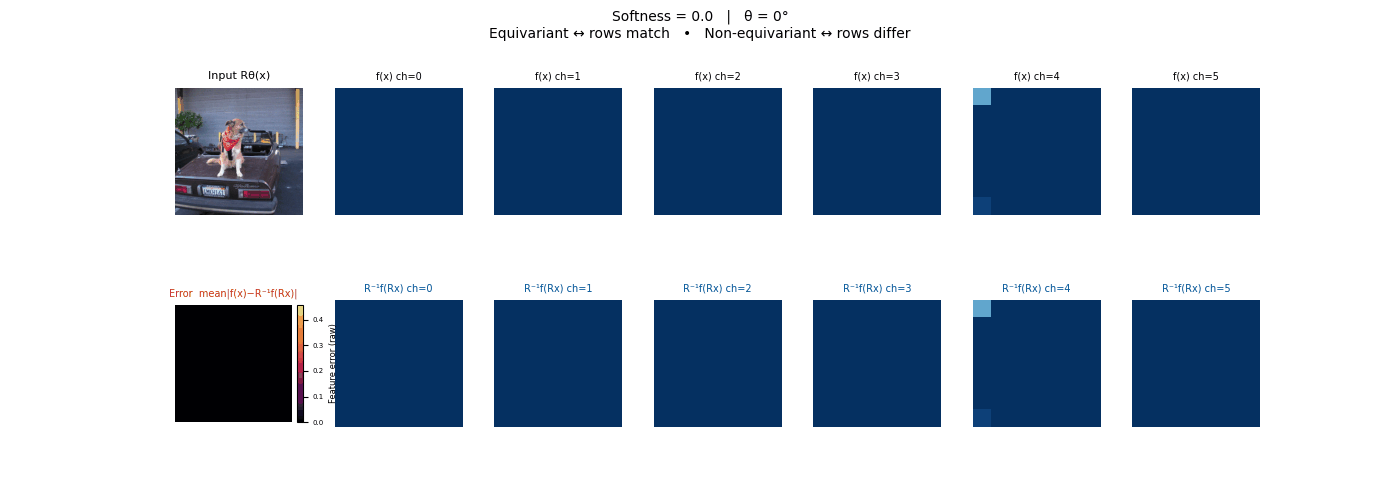

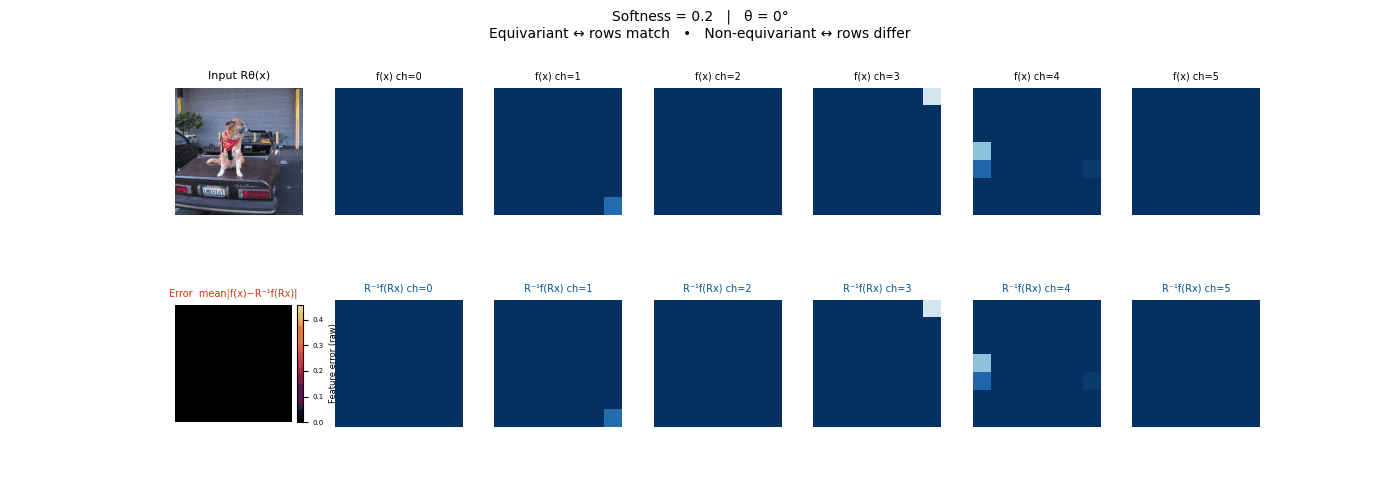

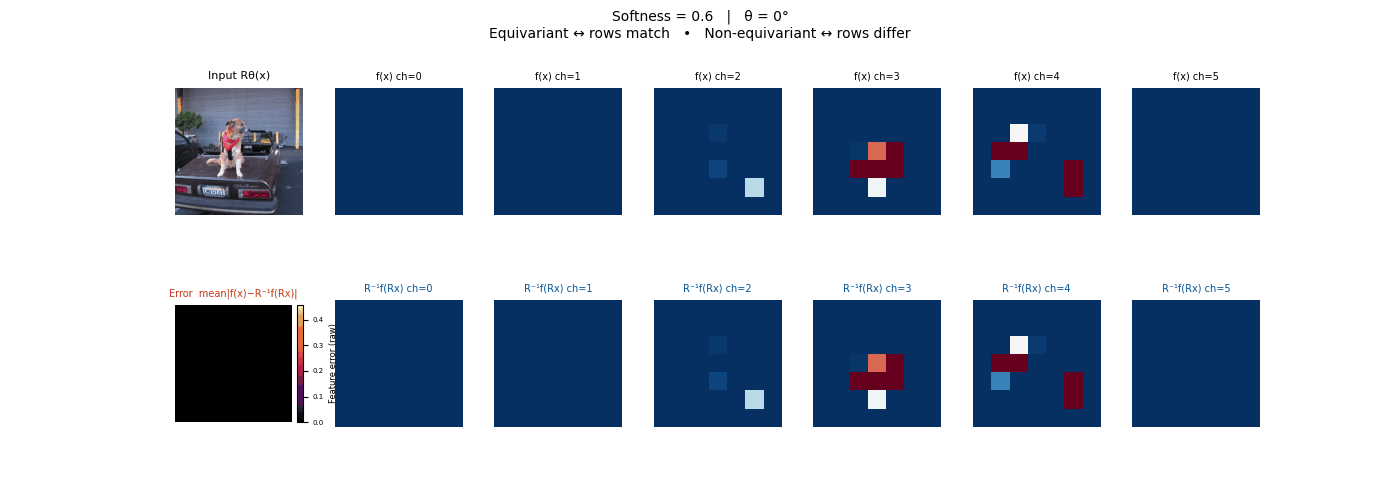

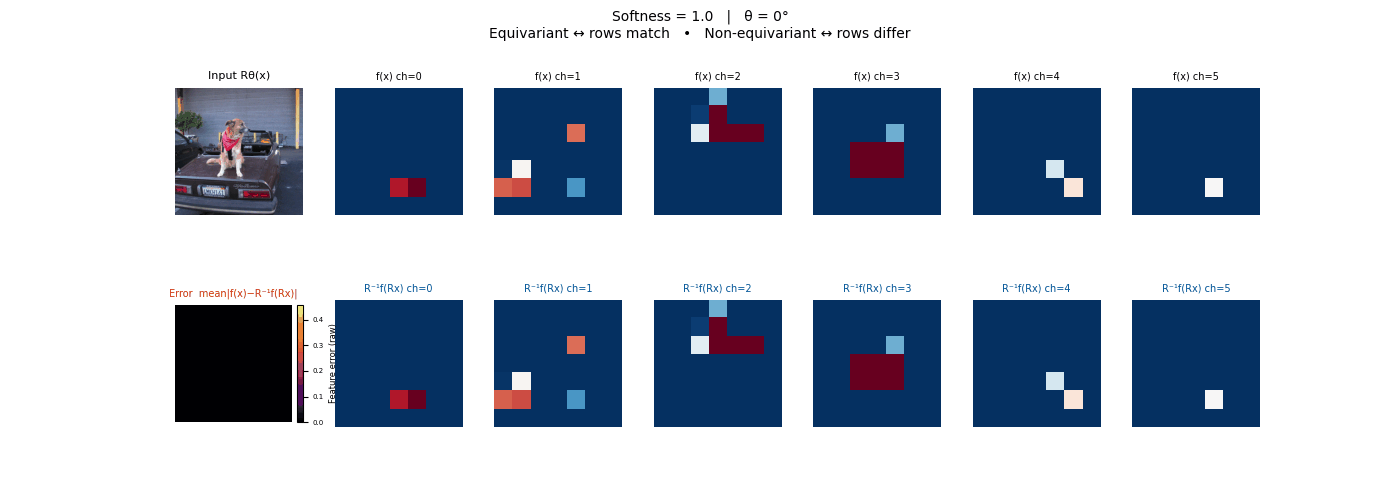

In [9]:
for s in softness_values:
    display(IPImage(filename=gif_paths[s]))